# EDA DATA CLEANING

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import re
import os

In [2]:
movies = pd.read_csv(r"..\data\movie_data.csv", encoding='utf-8',engine='python', on_bad_lines='skip')

In [3]:
movies.head()

,Unnamed: 0,adult,backdrop_path,movie_id,original_language,original_title,overview,popularity,poster_path,release_date,title,video,vote_average,vote_count,genres,keywords,cast,crew
0,0,False,/kQM7o3NIkruIZLoQ9E2XzZQ8Ujl.jpg,783461,hi,लूप लपेटा,"When her boyfriend loses a mobster's cash, Sav...",56.311,/onGdT8sYi89drvSJyEJnft97rOq.jpg,2022-02-04,Looop Lapeta,False,6.2,54.0,"[{'id': 28, 'name': 'Action'}, {'id': 35, 'nam...","['remake', 'looop lapeta', 'saade saati']","[{'adult': False, 'gender': 1, 'id': 550167, '...","[{'adult': False, 'gender': 2, 'id': 1071, 'kn..."
1,1,False,/7w06baRS9VPm5RYz8lawTCLiR4j.jpg,592508,hi,Sooryavanshi,"A fearless, faithful albeit slightly forgetful...",45.077,/8p3mhjyLjHKtaAv8tFKfvEBtir0.jpg,2021-11-05,Sooryavanshi,False,5.8,133.0,"[{'id': 28, 'name': 'Action'}, {'id': 80, 'nam...","['police', 'sequel', 'police officer', 'cop un...","[{'adult': False, 'gender': 2, 'id': 35070, 'k...","[{'adult': False, 'gender': 2, 'id': 35070, 'k..."
2,2,False,/sP9mRWiCxCuy17tUJfV8TpSZpqc.jpg,864692,hi,पठान,A soldier caught by enemies and presumed dead ...,47.611,/m1b9toKYyCujHuLoXB5GSDunO9e.jpg,2023-01-25,Pathaan,False,6.7,70.0,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...","['spy', 'fake death', 'spy thriller', 'spy uni...","[{'adult': False, 'gender': 2, 'id': 35742, 'k...","[{'adult': False, 'gender': 2, 'id': 35771, 'k..."
3,3,False,/vBmmJYv5asJpdJZsyPPc4MMpfBe.jpg,1018228,hi,चोर निकल के भागा,A flight attendant and her boyfriend must stea...,43.789,/1MIDERaEUMw1rYDM99tGZPY80Ap.jpg,2023-03-24,Chor Nikal Ke Bhaga,False,7.2,55.0,"[{'id': 80, 'name': 'Crime'}, {'id': 53, 'name...","['heist', 'airplane hijacking']","[{'adult': False, 'gender': 1, 'id': 1115720, ...","[{'adult': False, 'gender': 2, 'id': 102246, '..."
4,4,False,/u7kuUaySqXBVAtqEl9vkTkAzHV9.jpg,20453,hi,3 Idiots,Rascal. Joker. Dreamer. Genius... You've never...,37.260,/66A9MqXOyVFCssoloscw79z8Tew.jpg,2009-12-25,3 Idiots,False,8.0,2052.0,"[{'id': 18, 'name': 'Drama'}, {'id': 35, 'name...","['suicide', 'suicide attempt', 'college', 'mus...","[{'adult': False, 'gender': 2, 'id': 52763, 'k...","[{'adult': False, 'gender': 2, 'id': 35779, 'k..."


In [4]:
movies.tail(10)

,Unnamed: 0,adult,backdrop_path,movie_id,original_language,original_title,overview,popularity,poster_path,release_date,title,video,vote_average,vote_count,genres,keywords,cast,crew
15828,15861,False,/6Sg4UUs0OksCbR0TZxUtQWPOMDV.jpg,210860,en,Mortdecai,"An art dealer, Charles Mortdecai, searches for...",23.792,/j7eKGD0n1zRVfKMX6M1kpfavby7.jpg,2015-01-21,Mortdecai,False,5.5,2460.0,"[{'id': 35, 'name': 'Comedy'}, {'id': 12, 'nam...","['based on novel or book', 'painting', 'debt',...","[{'adult': False, 'gender': 2, 'id': 85, 'know...","[{'adult': False, 'gender': 2, 'id': 8221, 'kn..."
15829,15862,False,/6tyfdMfmLvPDMto1pKdUtuzN1Ku.jpg,43557,it,Merry Christmas,Four Italian men are suddenly involved in awkw...,4.860,/jNK5WEGYYKXio2DFsGHNlpEo0sU.jpg,2001-12-21,Merry Christmas,False,5.5,255.0,"[{'id': 35, 'name': 'Comedy'}]",[],"[{'adult': False, 'gender': 2, 'id': 69037, 'k...","[{'adult': False, 'gender': 2, 'id': 13159, 'k..."
15830,15863,False,/dkCeC92reZFKnZDspABZVpk0RLW.jpg,17047,en,Agent Cody Banks 2: Destination London,"With all-new gadgets, high-flying action, exci...",19.839,/l5CCDJV0VojPJedNcucPWBnrGaC.jpg,2004-03-12,Agent Cody Banks 2: Destination London,False,5.5,558.0,"[{'id': 35, 'name': 'Comedy'}, {'id': 28, 'nam...","['london, england', 'spy', 'cia', 'martial art...","[{'adult': False, 'gender': 2, 'id': 51391, 'k...","[{'adult': False, 'gender': 1, 'id': 3125, 'kn..."
15831,15864,False,/ylK7Wn5cgxXdede2WpK9lAbCsT0.jpg,9507,en,Runaway,"In the near future, a police officer specializ...",7.712,/8xMeKeXGHY2KbiMjSpEGqlIjAEp.jpg,1984-12-14,Runaway,False,5.5,200.0,"[{'id': 53, 'name': 'Thriller'}, {'id': 80, 'n...","['technology', 'future', 'chase', 'revenge', '...","[{'adult': False, 'gender': 2, 'id': 15112, 'k...","[{'adult': False, 'gender': 1, 'id': 597, 'kno..."
15832,15865,False,/nqPsqYFwuJgYz4EcLVSfGWUQlxf.jpg,255798,en,Burying the Ex,Before horror enthusiast Max can break things ...,13.248,/jf3MWdCo8eM5AJeyy21xISRSyfe.jpg,2014-09-04,Burying the Ex,False,5.5,412.0,"[{'id': 35, 'name': 'Comedy'}, {'id': 27, 'nam...","['halloween', 'dark comedy', 'zombie']","[{'adult': False, 'gender': 2, 'id': 21028, 'k...","[{'adult': False, 'gender': 2, 'id': 4600, 'kn..."
15833,15866,False,/rZuWszvhtnSHRKtAwLgS4Gw0qSP.jpg,77663,en,Killing Season,"Two veterans of the Bosnian War, one American,...",14.704,/o55HXx21PqRcOgAaOWFz4tGMrZh.jpg,2013-07-12,Killing Season,False,5.5,875.0,"[{'id': 28, 'name': 'Action'}, {'id': 53, 'nam...","['hunter', 'bosnia and herzegovina', 'cabin', ...","[{'adult': False, 'gender': 2, 'id': 380, 'kno...","[{'adult': False, 'gender': 2, 'id': 19155, 'k..."
15834,15867,False,/p1Z3ExMNc1sidmo12vgxl2pZsED.jpg,14435,en,My Bloody Valentine,"Ten years ago, a tragedy changed the town of H...",15.926,/9biIVOMTdvv4aj4a5HClmrK5EHB.jpg,2009-01-16,My Bloody Valentine,False,5.5,991.0,"[{'id': 9648, 'name': 'Mystery'}, {'id': 27, '...","['sheriff', 'miner', 'delusion', 'head injury'...","[{'adult': False, 'gender': 2, 'id': 49624, 'k...","[{'adult': False, 'gender': 1, 'id': 13585, 'k..."
15835,15868,False,/7LpFPbE1AdzGQnO5Ib7fpSRMsvd.jpg,9022,en,All the Boys Love Mandy Lane,"Beautiful Mandy Lane isn't a party girl but, w...",12.071,/9t7n7K0xqw0gMvrxyhdiyqEF3W1.jpg,2006-09-09,All the Boys Love Mandy Lane,False,5.5,567.0,"[{'id': 27, 'name': 'Horror'}, {'id': 9648, 'n...","['suicide attempt', 'gun', 'texas', 'mass murd...","[{'adult': False, 'gender': 1, 'id': 55085, 'k...","[{'adult': False, 'gender': 2, 'id': 56661, 'k..."
15836,15869,False,/rCzYrGstiybMwDPcZlePAN7IWBh.jpg,512025,en,There's Someone Inside Your House,"As the countdown to graduation begins, student...",18.521,/GaPJQscaH4MtYQTbJyWjCUIho8.jpg,2021-09-24,There's Someone Inside Your House,False,5.5,543.0,"[{'id': 53, 'name': 'Thriller'}, {'id': 27, 'n...","['based on novel or book', 'small town', 'high...","[{'adult': False, 'gender': 1, 'id': 1001946, ...","[{'adult': False, 'gender': 2, 'id': 2127, 'kn..."
15837,15870,False,/of1EpT8iYFfiF1b0Bo3PPHjyAzi.j

In [5]:
movies.shape

(15838, 18)

In [6]:
print('Number of Rows',movies.shape[0])
print('Number of Columns',movies.shape[1])

Number of Rows 15838
Number of Columns 18


In [7]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15838 entries, 0 to 15837
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15838 non-null  object 
 1   adult              15838 non-null  object 
 2   backdrop_path      12987 non-null  object 
 3   movie_id           15838 non-null  object 
 4   original_language  15838 non-null  object 
 5   original_title     15838 non-null  object 
 6   overview           15622 non-null  object 
 7   popularity         15836 non-null  float64
 8   poster_path        15184 non-null  object 
 9   release_date       15836 non-null  object 
 10  title              15836 non-null  object 
 11  video              15836 non-null  object 
 12  vote_average       15834 non-null  float64
 13  vote_count         15834 non-null  float64
 14  genres             15834 non-null  object 
 15  keywords           15834 non-null  object 
 16  cast               158

<!-- ## Drop irrelevant columns -->

In [8]:
movies.isna().sum()

Unnamed: 0              0
adult                   0
backdrop_path        2851
movie_id                0
original_language       0
original_title          0
overview              216
popularity              2
poster_path           654
release_date            2
title                   2
video                   2
vote_average            4
vote_count              4
genres                  4
keywords                4
cast                    4
crew                    4
dtype: int64

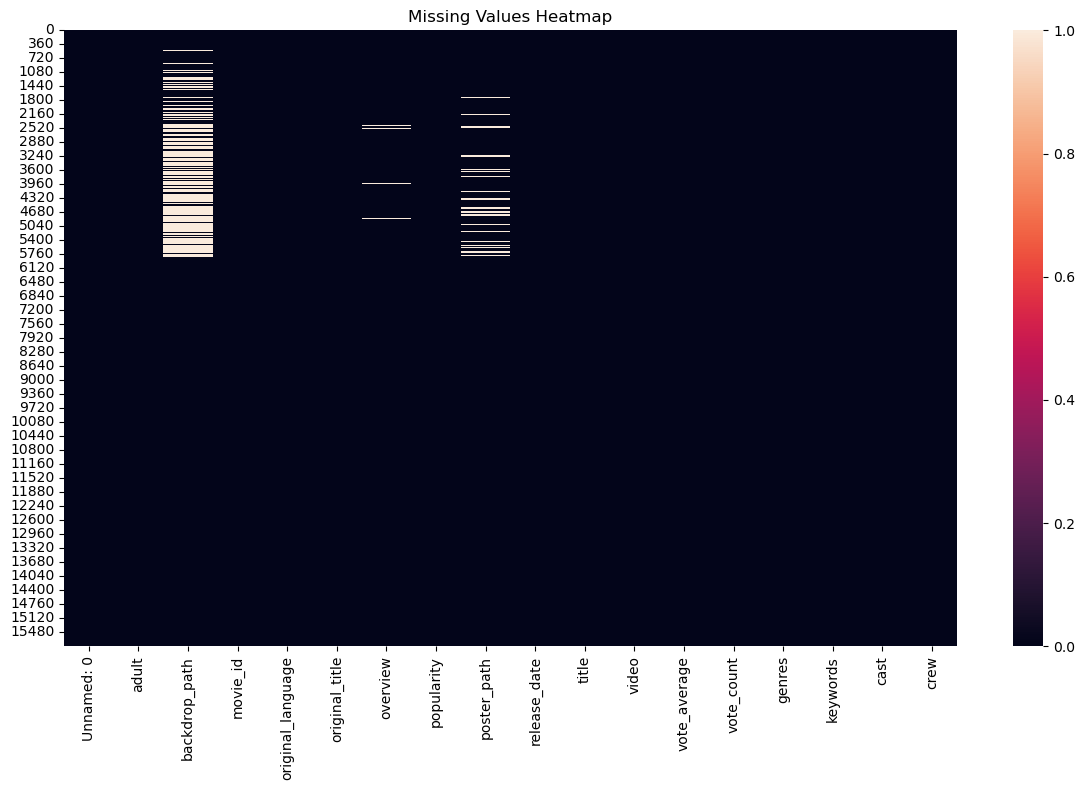

In [9]:
plt.figure(figsize=(12, 8))
sns.heatmap(movies.isna())
plt.title('Missing Values Heatmap')
plt.tight_layout()

In [10]:
per_missing = movies.isnull().sum() * 100 / len(movies)
per_missing

Unnamed: 0            0.000000
adult                 0.000000
backdrop_path        18.001010
movie_id              0.000000
original_language     0.000000
original_title        0.000000
overview              1.363809
popularity            0.012628
poster_path           4.129309
release_date          0.012628
title                 0.012628
video                 0.012628
vote_average          0.025256
vote_count            0.025256
genres                0.025256
keywords              0.025256
cast                  0.025256
crew                  0.025256
dtype: float64

In [11]:
movies['release_date'] = pd.to_datetime(movies['release_date'], errors='coerce')
movies['release_date'] = movies['release_date'].fillna(movies['release_date'].min())

In [12]:
movies['vote_average'] = movies['vote_average'].fillna(movies['vote_average'].mean())
movies['vote_count'] = movies['vote_count'].fillna(movies['vote_count'].median())

In [13]:
movies.duplicated().sum()

np.int64(0)

In [14]:
movies.describe()

,popularity,release_date,vote_average,vote_count
count,15836.000000,15838,15838.000000,15838.000000
mean,17.859539,2001-03-28 01:02:05.924990592,5.599406,1006.254009
min,0.600000,1895-06-10 00:00:00,0.000000,0.000000
25%,1.735750,1990-12-21 00:00:00,5.700000,3.000000
50%,10.070500,2007-06-13 12:00:00,6.400000,291.000000
75%,17.148250,2016-06-24 00:00:00,7.100000,855.750000
max,9065.306000,2026-12-08 00:00:00,10.000000,29497.000000
std,114.113372,NaN,2.557057,2249.951204


In [15]:
movies.describe(include='all')

,Unnamed: 0,adult,backdrop_path,movie_id,original_language,original_title,overview,popularity,poster_path,release_date,title,video,vote_average,vote_count,genres,keywords,cast,crew
count,15838,15838,12987,15838,15838,15838,15622,15836.000000,15184,15838,15836,15836,15838.000000,15838.000000,15834,15834,15834,15834
unique,15838,3,12937,15789,46,15236,15551,NaN,15135,NaN,15027,3,NaN,NaN,2437,10143,15313,15350
top,15870,False,/u7kuUaySqXBVAtqEl9vkTkAzHV9.jpg,10757,en,देवदास,A 1999 Indian horror film.,NaN,/vKLp0X2RQOuA31R3AdaYtDdKIPK.jpg,NaN,Hero,False,NaN,NaN,"[{'id': 18, 'name': 'Drama'}]",[],[],[]
freq,1,15836,2,2,7605,4,6,NaN,2,NaN,4,15834,NaN,NaN,1407,5204,522,485
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.859539,NaN,2001-03-28 01:02:05.924990592,NaN,NaN,5.599406,1006.254009,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.600000,NaN,1895-06-10 00:00:00,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.735750,NaN,1990-12-21 00:00:00,NaN,NaN,5.700000,3.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.070500,NaN,2007-06-13 12:00:00,NaN,NaN,6.400000,291.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.148250,NaN,2016-06-24 00:00:00,NaN,NaN,7.100000,855.750000,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9065.306000,NaN,2026-12-08 00:00:00,NaN,NaN,10.000000,29497.000000,NaN,NaN,NaN,NaN


In [16]:
movies.columns

Index(['Unnamed: 0', 'adult', 'backdrop_path', 'movie_id', 'original_language',
       'original_title', 'overview', 'popularity', 'poster_path',
       'release_date', 'title', 'video', 'vote_average', 'vote_count',
       'genres', 'keywords', 'cast', 'crew'],
      dtype='object')

In [17]:
movies.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')

In [18]:
movies['release_date'].value_counts()

release_date
1967-01-01    27
1974-01-01    25
1971-01-01    23
1962-01-01    22
1963-01-01    22
              ..
2018-02-04     1
2006-07-13     1
2007-10-03     1
2008-04-28     1
2009-10-20     1
Name: count, Length: 8015, dtype: int64

In [19]:
movies['release_date'] = pd.to_datetime(movies['release_date'], errors='coerce')

In [20]:
movies['release_year'] = movies['release_date'].dt.year

In [21]:
movies['release_year'].value_counts().sort_index()

release_year
1895      5
1902      1
1903      1
1911      1
1915      1
       ... 
2022    480
2023    119
2024      4
2025      1
2026      1
Name: count, Length: 115, dtype: int64

In [22]:
movies['release_year'] = movies['release_year'].astype('Int64')
movies['release_year'].value_counts().sort_index()

release_year
1895      5
1902      1
1903      1
1911      1
1915      1
       ... 
2022    480
2023    119
2024      4
2025      1
2026      1
Name: count, Length: 115, dtype: Int64

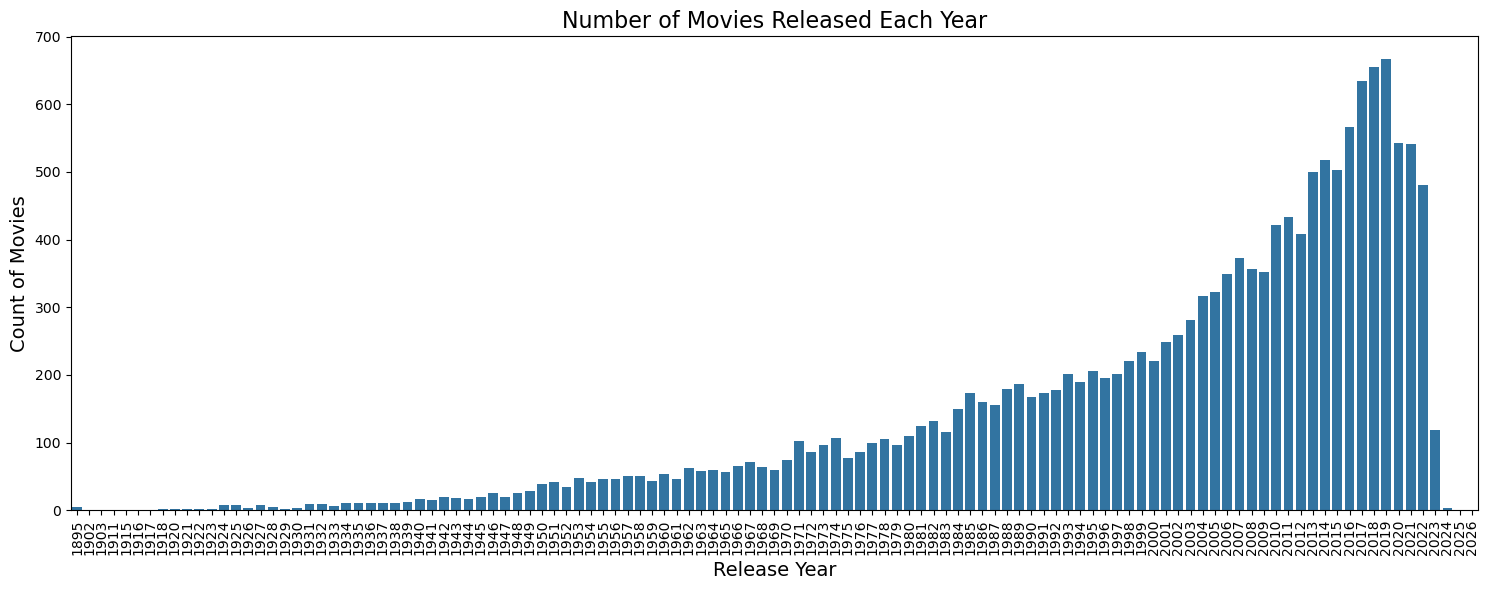

In [23]:
year_counts = movies['release_year'].value_counts().sort_index()

plt.figure(figsize=(15,6))
sns.barplot(x=year_counts.index, y=year_counts.values)

plt.title("Number of Movies Released Each Year", fontsize=16)
plt.xlabel("Release Year", fontsize=14)
plt.ylabel("Count of Movies", fontsize=14)

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [24]:
movies['popularity'].value_counts().sort_index(ascending=False)

popularity
9065.306       1
5827.392       1
5253.149       1
4810.649       1
3571.437       1
            ... 
0.605          3
0.603          4
0.602          3
0.601          6
0.600       1561
Name: count, Length: 10621, dtype: int64

In [25]:
top10_popular = movies.nlargest(10, 'popularity')[['title', 'popularity']]
print(top10_popular)

                                  title  popularity
7132        The Super Mario Bros. Movie    9065.306
9571           Shazam! Fury of the Gods    5827.392
8058                          Creed III    5253.149
6638           Avatar: The Way of Water    4810.649
12168                  Murder Mystery 2    3571.437
12695                                65    1918.606
5942       Puss in Boots: The Last Wish    1878.108
6162               John Wick: Chapter 4    1840.121
11780                      Cocaine Bear    1550.773
15151  Winnie the Pooh: Blood and Honey    1187.936


In [ ]:
min_popularity = movies['popularity'].min()

print("Minimum popularity:", min_popularity)

Minimum popularity: 0.6


In [ ]:
max_popularity = movies['popularity'].max()

print("Maximum popularity:", max_popularity)

Maximum popularity: 9065.306


In [ ]:
movies[movies['popularity'] == movies['popularity'].min()]

,adult,backdrop_path,movie_id,original_language,original_title,overview,popularity,poster_path,release_date,title,video,vote_average,vote_count,genres,keywords,cast,crew,release_year
3431,False,/perU9ll10lmDbxmuZiPXjbRPZz1.jpg,159630,hi,Holi,"In a typical college in a typical Indian city,...",0.6,/mhNQ8YfJcUuMl9OPOcMlmtTJZH9.jpg,1984-08-15,Holi,False,5.8,4.0,[],[],"[{'adult': False, 'gender': 2, 'id': 52763, 'k...","[{'adult': False, 'gender': 2, 'id': 1066440, ...",1984
3436,False,NaN,431959,hi,Khal-Naaikaa,The lesser known Bollywood remake of The Hand ...,0.6,/1P0Uy3rKVh1nlBS6bDoHKkErB4B.jpg,1993-08-06,Khal-Naaikaa,False,10.0,1.0,"[{'id': 53, 'name': 'Thriller'}]",[],"[{'adult': False, 'gender': 2, 'id': 616995, '...","[{'adult': False, 'gender': 2, 'id': 1032627, ...",1993
3437,False,/mSVQb7ifhIcTj93gsIVRGSpYmMt.jpg,338126,hi,Jeete Hain Shaan Se,"Johny, Govinda, and Iqbal Ali are three close ...",0.6,/voX0TXjRoE4aB0XoF4iMY5sBa7D.jpg,1987-01-01,Jeete Hain Shaan Se,False,10.0,1.0,"[{'id': 18, 'name': 'Drama'}, {'id': 28, 'name...",[],"[{'adult': False, 'gender': 2, 'id': 85450, 'k...","[{'adult': False, 'gender': 0, 'id': 2115374, ...",1987
3441,False,/e6nZnXRFAUi8pujMtQ3rM9QQeYq.jpg,240307,hi,बालिका बधू,"In a village circa the British rule in India, ...",0.6,/uXIEuRhwSa4m673fGI6DY0zuTO2.jpg,1976-08-20,Balika Badhu,False,9.0,2.0,"[{'id': 18, 'name': 'Drama'}, {'id': 10749, 'n...",[],"[{'adult': False, 'gender': 2, 'id': 994514, '...","[{'adult': False, 'gender': 2, 'id': 88141, 'k...",1976
3444,False,/b2Z4K0nkshpkkk9WXgkFUj7xS4V.jpg,168490,hi,Daraar,"Raj Malhotra lives with his mother, and comes ...",0.6,/iFOGHTtmCuujqJZh8X02fmJhD42.jpg,1996-07-05,Daraar,False,8.3,3.0,"[{'id': 53, 'name': 'Thriller'}, {'id': 18, 'n...",[],"[{'adult': False, 'gender': 2, 'id': 35791, 'k...","[{'adult': False, 'gender': 2, 'id': 87355, 'k...",1996
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5910,False,/qknxyRgP6UTmwJ4B9tDAmzHMq7u.jpg,92321,ja,蛍火の杜へ,One hot summer day a little girl gets lost in ...,0.6,/mDqzHV8UXWWNpZkoAbKmKX1ZxEE.jpg,2011-09-17,Hotarubi no Mori e,False,8.4,932.0,"[{'id': 10749, 'name': 'Romance'}, {'id': 16, ...","['supernatural', 'slice of life', 'based on ma...","[{'adult': False, 'gender': 1, 'id': 1315197, ...","[{'adult': False, 'gender': 1, 'id': 144665, '...",2011
9818,False,/hkVa4TVi0u0hOqmivehcTN6YUH7.jpg,203819,en,Tracks,Accompanied only by her faithful dog and four ...,0.6,/qDSA80DC8BmBrErQsiL23qwoeCw.jpg,2013-12-19,Tracks,False,6.9,455.0,"[{'id': 12, 'name': 'Adventure'}, {'id': 18, '...","['camel', 'biography', 'australia', 'based on ...","[{'adult': False, 'gender': 1, 'id': 76070, 'k...","[{'adult': False, 'gender': 2, 'id': 37270, 'k...",2013
9879,False,/2OPIWYGSRUPc0UPiA0Xn4gG7CBe.jpg,11367,it,Pari e dispari,A bumbling government agent recruits a trucker...,0.6,/ankqh5ykTnjXiDizWtnbKRu8LPo.jpg,1978-10-28,Odds and Evens,False,6.9,339.0,"[{'id': 35, 'name': 'Comedy'}, {'id': 80, 'nam...","['casino', 'florida', 'intelligence', 'gangste...","[{'adult': False, 'gender': 2, 'id': 15140, 'k...","[{'adult': False, 'gender': 0, 'id': 5559, 'kn...",1978
11910,False,/ltji3cISxWL83DW5ngYxI89MepJ.jpg,203793,ru,Сталинград,A band of determined Russian soldiers fight to...,0.6,/pk2d5ahR9g4R3YDlhNA5m1vHhFv.jpg,2013-10-09,Stalingrad,False,6.5,291.0,"[{'id': 10752, 'name': 'War'}, {'id': 28, 'nam...","['world war ii', 'soviet union', 'nazi', 'sovi...","[{'adult': False, 'gender': 2, 'id': 3491, 'kn...","[{'adult': False, 'gender': 2, 'id': 5628, 'kn...",2013


In [29]:
movies['vote_average'].value_counts().sort_index(ascending=False)

vote_average
10.0     251
9.8        1
9.5       12
9.4        1
9.3        2
        ... 
1.5        4
1.3        2
1.0       46
0.5        3
0.0     2343
Name: count, Length: 81, dtype: int64

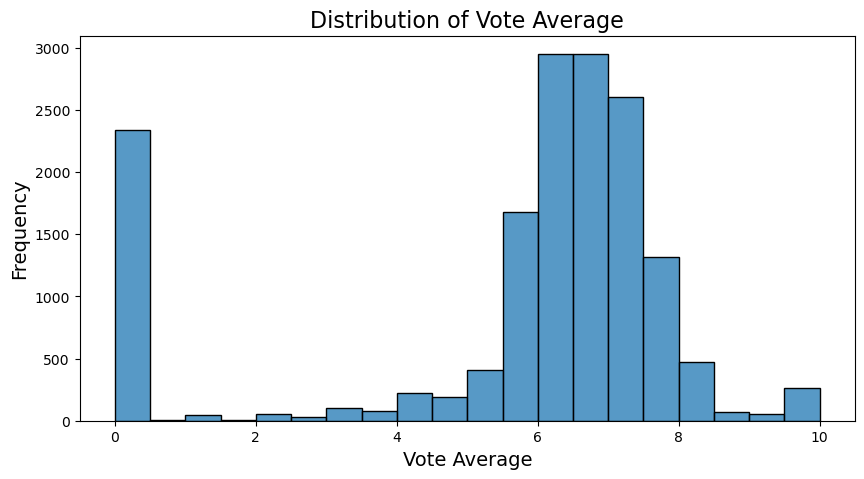

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.histplot(movies['vote_average'], bins=20)

plt.title("Distribution of Vote Average", fontsize=16)
plt.xlabel("Vote Average", fontsize=14)
plt.ylabel("Frequency", fontsize=14)

plt.show()

In [31]:
movies['vote_count'].astype(int).value_counts().sort_index(ascending=False)

vote_count
29497       1
28208       1
26186       1
25725       1
24960       1
         ... 
4         212
3         315
2         441
1         883
0        2343
Name: count, Length: 3395, dtype: int64

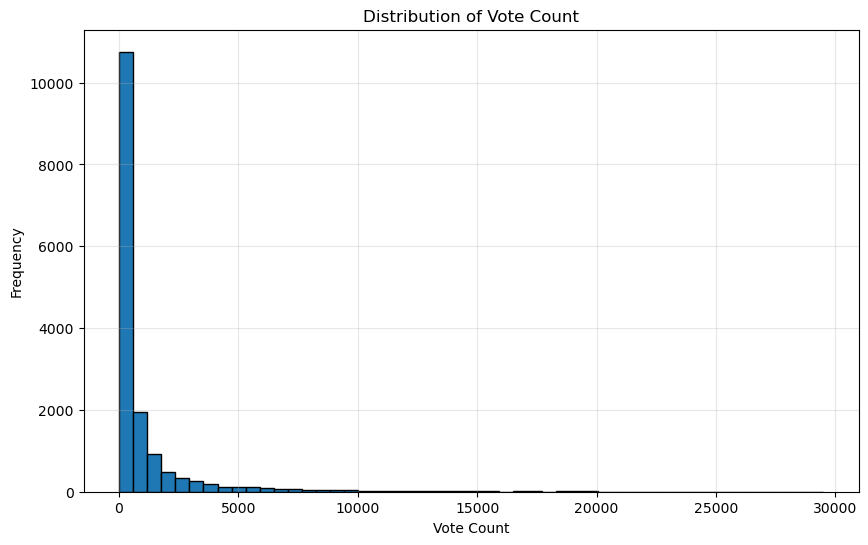

In [32]:
plt.figure(figsize=(10,6))
plt.hist(movies['vote_count'], bins=50, edgecolor='black')
plt.xlabel("Vote Count")
plt.ylabel("Frequency")
plt.title("Distribution of Vote Count")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Demographic Filtering
m = movies['vote_count'].quantile(0.9)
C = movies['vote_average'].mean()
print("m:", m, " C:", C)

m: 2574.0  C: 5.599406340785651


In [34]:
def weight_average(x):
    v = x['vote_count']
    R = x['vote_average']
    return (v/(v+m))*R + (m/(v+m))*C

In [35]:
movies['score'] = movies.apply(weight_average, axis=1)

In [36]:
movies.shape

(15838, 19)

In [37]:
top10 = movies.sort_values('score' , ascending = False)
top10[['title','score','vote_average','vote_count']].head(10)

,title,score,vote_average,vote_count
5874,The Shawshank Redemption,8.394884,8.7,23583.0
5873,The Godfather,8.306986,8.7,17733.0
5883,The Dark Knight,8.267200,8.5,29497.0
5885,Pulp Fiction,8.228840,8.5,24960.0
5887,Forrest Gump,8.223804,8.5,24458.0
5890,The Lord of the Rings: The Return of the King,8.188730,8.5,21412.0
5902,Fight Club,8.149349,8.4,26186.0
5877,Schindler's List,8.132502,8.6,13947.0
5911,The Lord of the Rings: The Fellowship of the Ring,8.112605,8.4,22509.0
5882,Parasite,8.088098,8.5,15552.0


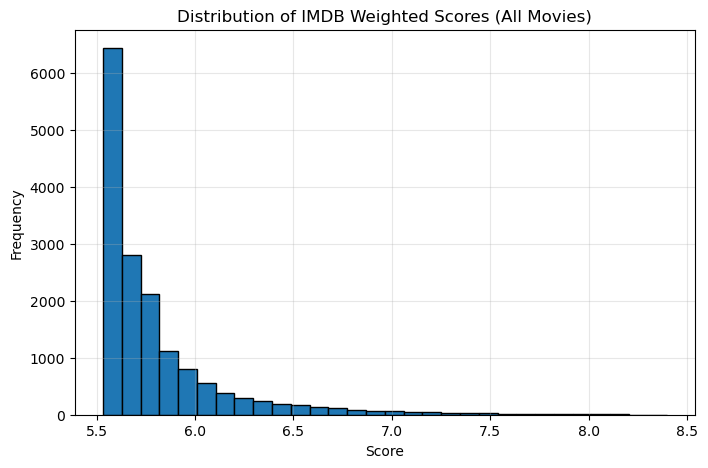

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(movies['score'], bins=30, edgecolor='black')
plt.title('Distribution of IMDB Weighted Scores (All Movies)')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.show()

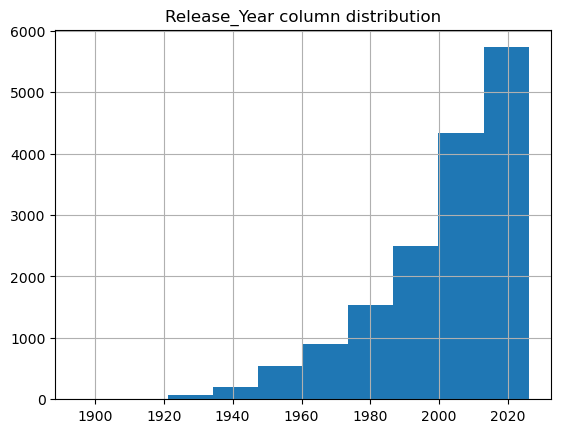

In [39]:
movies['release_year'].hist()
plt.title('Release_Year column distribution')
plt.show()

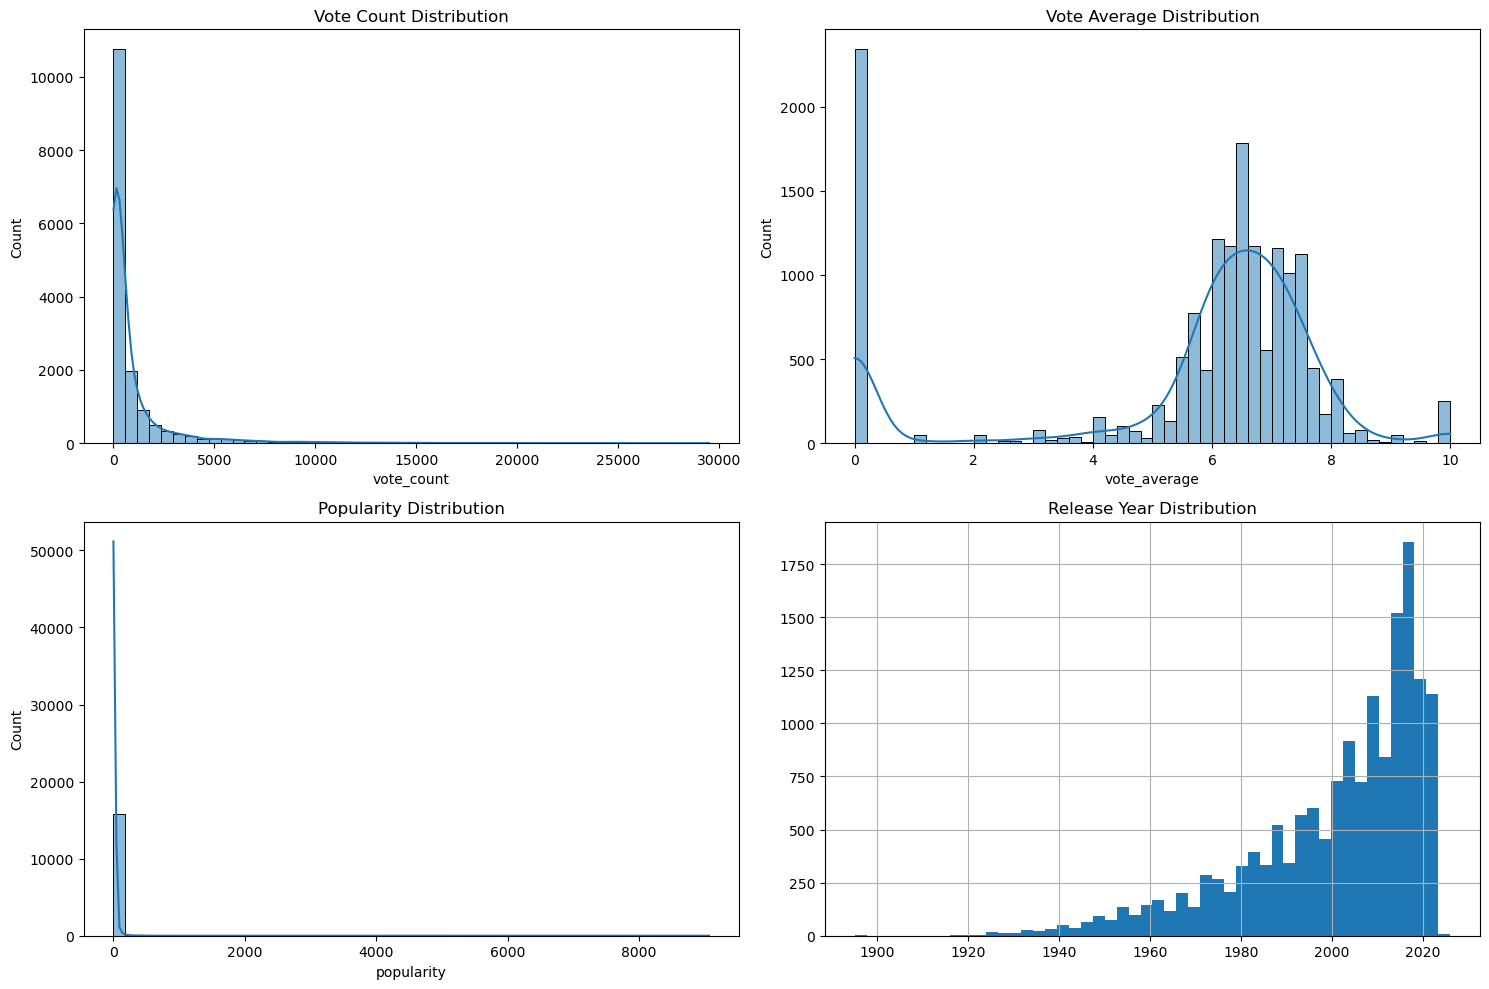

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.histplot(movies['vote_count'], bins=50, ax=axes[0,0], kde=True)
axes[0,0].set_title('Vote Count Distribution')

sns.histplot(movies['vote_average'], bins=50, ax=axes[0,1], kde=True)
axes[0,1].set_title('Vote Average Distribution')

sns.histplot(movies['popularity'], bins=50, ax=axes[1,0], kde=True)
axes[1,0].set_title('Popularity Distribution')

movies['release_year'].hist(bins=50, ax=axes[1,1])
axes[1,1].set_title('Release Year Distribution')

plt.tight_layout()
plt.show()


In [41]:
movies = movies.dropna(subset=["title"])

In [42]:
movies["overview"] = movies["overview"].fillna("")

In [43]:
# Fill list columns with empty lists
movies["genres"] = movies["genres"].fillna("[]")
movies["keywords"] = movies["keywords"].fillna("[]")
movies["cast"] = movies["cast"].fillna("[]")
movies["crew"] = movies["crew"].fillna("[]")

In [44]:
import ast

movies["genres"] = movies["genres"].apply(ast.literal_eval)
movies["keywords"] = movies["keywords"].apply(ast.literal_eval)
movies["cast"] = movies["cast"].apply(ast.literal_eval)
movies["crew"] = movies["crew"].apply(ast.literal_eval)

In [45]:
import ast

# Convert stringified lists to real lists
movies['crew'] = movies['crew'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)


In [46]:
def get_director(crew):
    for person in crew:
        if person.get("job") == "Director":
            return person["name"]
    return ""
movies["director"] = movies["crew"].apply(get_director)
movies["director"]

0              Aakash Bhatia
1               Rohit Shetty
2            Siddharth Anand
3                 Ajay Singh
4            Rajkumar Hirani
                ...         
15833    Mark Steven Johnson
15834        Patrick Lussier
15835        Jonathan Levine
15836          Patrick Brice
15837            Walt Becker
Name: director, Length: 15836, dtype: object

In [47]:
def top_three_crew(x):
    if isinstance(x, list):
        return [member.get("name", "") for member in x[:3]]
    return []

In [48]:
movies["crew"] = movies["crew"].apply(top_three_crew)

In [49]:
movies["crew"][0]

['Tom Tykwer', 'Mukesh Chhabra', 'Tanuj Garg']

In [50]:
movies['cast'][0]

[{'adult': False,
  'gender': 1,
  'id': 550167,
  'known_for_department': 'Acting',
  'name': 'Taapsee Pannu',
  'original_name': 'Taapsee Pannu',
  'popularity': 6.156,
  'profile_path': '/u9Gwg3J0bdczTPunP8qoWK2Vhu4.jpg',
  'cast_id': 1,
  'character': 'Savi',
  'credit_id': '5ff5b30128723c0040af9605',
  'order': 0},
 {'adult': False,
  'gender': 2,
  'id': 1714229,
  'known_for_department': 'Acting',
  'name': 'Tahir Raj Bhasin',
  'original_name': 'Tahir Raj Bhasin',
  'popularity': 2.203,
  'profile_path': '/A4ylMYWj8IqnmX74Two8c4Lp8jY.jpg',
  'cast_id': 3,
  'character': 'Satya',
  'credit_id': '5ff5b31dd38b580043cb4047',
  'order': 1},
 {'adult': False,
  'gender': 1,
  'id': 2092738,
  'known_for_department': 'Acting',
  'name': 'Shreya Dhanwanthary',
  'original_name': 'Shreya Dhanwanthary',
  'popularity': 8.802,
  'profile_path': '/dSWHYuEWjPzczAzdLFgYHt3Y5Dd.jpg',
  'cast_id': 15,
  'character': 'Julia',
  'credit_id': '6136133e2cde980089dc0082',
  'order': 2},
 {'adult': 

In [51]:
movies["cast"] = movies["cast"].apply(lambda x: [i["name"] for i in x[:5]])
movies["cast"]

0        [Taapsee Pannu, Tahir Raj Bhasin, Shreya Dhanw...
1        [Akshay Kumar, Katrina Kaif, Ajay Devgn, Ranve...
2        [Shah Rukh Khan, Deepika Padukone, John Abraha...
3        [Yami Gautam, Sunny Kaushal, Sharad Kelkar, In...
4        [Aamir Khan, R. Madhavan, Sharman Joshi, Karee...
                               ...                        
15833    [Robert De Niro, John Travolta, Milo Ventimigl...
15834    [Jensen Ackles, Jaime King, Kerr Smith, Betsy ...
15835    [Amber Heard, Michael Welch, Whitney Able, Ans...
15836    [Sydney Park, Théodore Pellerin, Asjha Cooper,...
15837    [John Travolta, Robin Williams, Kelly Preston,...
Name: cast, Length: 15836, dtype: object

In [52]:
movies["genres"] = movies["genres"].apply(lambda x: [i["name"] for i in x])

In [53]:
movies["keywords"]

0                      [remake, looop lapeta, saade saati]
1           [police, sequel, police officer, cop universe]
2        [spy, fake death, spy thriller, spy universe, ...
3                              [heist, airplane hijacking]
4        [suicide, suicide attempt, college, musical, s...
                               ...                        
15833    [hunter, bosnia and herzegovina, cabin, baptis...
15834    [sheriff, miner, delusion, head injury, remake...
15835    [suicide attempt, gun, texas, mass murder, far...
15836    [based on novel or book, small town, high scho...
15837    [camp, best friend, co-workers relationship, d...
Name: keywords, Length: 15836, dtype: object

In [ ]:
import ast

def extract_keywords(x):
    if isinstance(x, list):
        return [d.get("name", "") for d in x if isinstance(d, dict)]
    
    if x is None or x == "" or (isinstance(x, float) and pd.isna(x)):
        return []
    
    try:
        parsed = ast.literal_eval(x)
        if isinstance(parsed, list):
            return [d.get("name", "") for d in parsed if isinstance(d, dict)]
        else:
            return []
    except:
        return []


In [55]:
# movies['genres']
movies["genres"]

0              [Action, Comedy, Crime]
1            [Action, Crime, Thriller]
2        [Action, Adventure, Thriller]
3                    [Crime, Thriller]
4                      [Drama, Comedy]
                     ...              
15833               [Action, Thriller]
15834                [Mystery, Horror]
15835      [Horror, Mystery, Thriller]
15836      [Thriller, Horror, Mystery]
15837                 [Comedy, Family]
Name: genres, Length: 15836, dtype: object

In [ ]:
for idx, row in movies.head(10).iterrows():
    print(row['title'], ":", row['genres'])

Looop Lapeta : ['Action', 'Comedy', 'Crime']
Sooryavanshi : ['Action', 'Crime', 'Thriller']
Pathaan : ['Action', 'Adventure', 'Thriller']
Chor Nikal Ke Bhaga : ['Crime', 'Thriller']
3 Idiots : ['Drama', 'Comedy']
My Name Is Khan : ['Drama', 'Romance']
Dilwale Dulhania Le Jayenge : ['Comedy', 'Drama', 'Romance']
Dhamaka : ['Thriller', 'Drama', 'Crime']
Brahmāstra Part One: Shiva : ['Action', 'Adventure', 'Fantasy']
Andhadhun : ['Crime', 'Thriller', 'Comedy']


In [57]:
from collections import Counter

genre_counter = Counter()

for g in movies['genres']:
    genre_counter.update(g)

genre_counts = pd.DataFrame.from_dict(genre_counter, orient='index', columns=['count'])
genre_counts = genre_counts.sort_values('count', ascending=False)

genre_counts

,count
Drama,7548
Comedy,4686
Thriller,3305
Action,3290
Romance,3054
Crime,2071
Adventure,1688
Family,1493
Horror,1483
Fantasy,1182


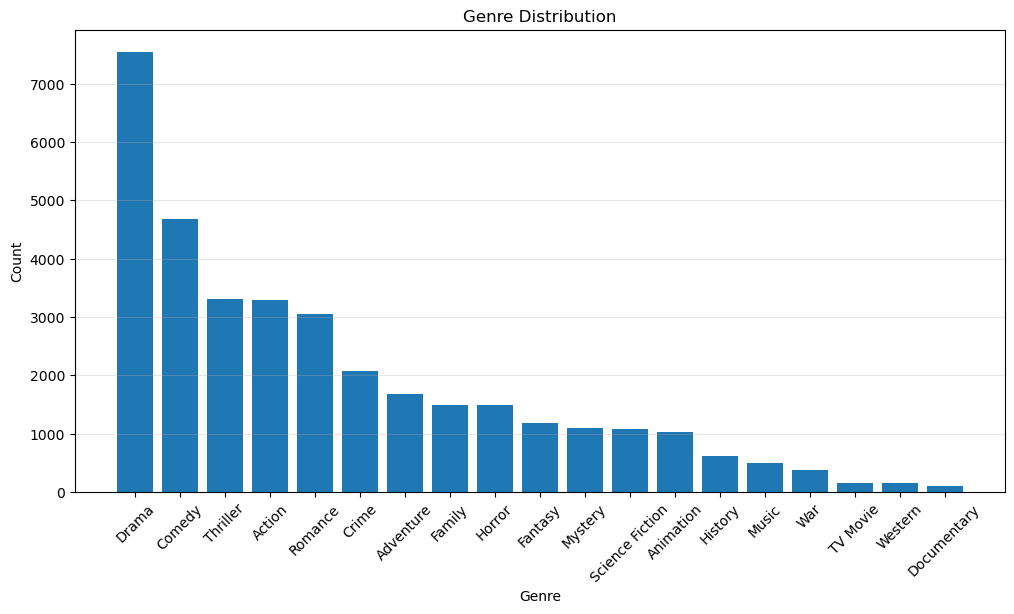

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.bar(genre_counts.index, genre_counts['count'])
plt.xticks(rotation=45)
plt.title("Genre Distribution")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.grid(axis='y', alpha=0.3)
plt.show()

In [59]:
import numpy as np

genre_avg_rating = {}

for genre in genre_counter.keys():
    mask = movies['genres'].apply(lambda g: genre in g)
    genre_avg_rating[genre] = movies.loc[mask, 'vote_average'].mean()

genre_avg_df = pd.DataFrame.from_dict(genre_avg_rating, orient='index', columns=['avg_rating'])
genre_avg_df = genre_avg_df.sort_values('avg_rating', ascending=False)

genre_avg_df

,avg_rating
Western,6.944737
War,6.928150
Animation,6.835597
Fantasy,6.627411
TV Movie,6.617391
History,6.605041
Adventure,6.533590
Science Fiction,6.499076
Mystery,6.276251
Comedy,6.212785


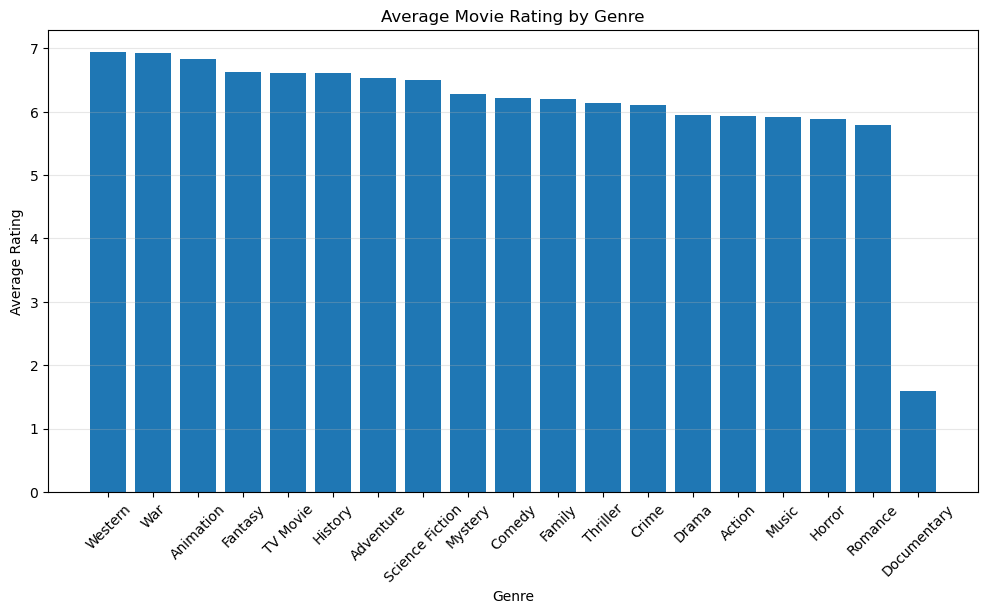

In [60]:
plt.figure(figsize=(12,6))
plt.bar(genre_avg_df.index, genre_avg_df['avg_rating'])
plt.xticks(rotation=45)
plt.title("Average Movie Rating by Genre")
plt.xlabel("Genre")
plt.ylabel("Average Rating")
plt.grid(axis='y', alpha=0.3)
plt.show()

In [61]:
movies['original_language'].unique()

array(['hi', 'FryDay', 'Paramaatma', 'en', 'es', 'ja', 'ko', 'it', 'pt',
       'zh', 'ru', 'fr', 'tr', 'sv', 'hu', 'ar', 'de', 'cn', 'da', 'pl',
       'bn', 'nl', 'fa', 'th', 'te', 'sr', 'sh', 'et', 'id', 'cs', 'uk',
       'no', 'ro', 'gl', 'el', 'bs', 'hy', 'fi', 'is', 'ml', 'la', 'af',
       'eu', 'nb', 'he', 'km'], dtype=object)

In [62]:
lang_map = {
    'hi': 'Hindi',
    'en': 'English',
    'es': 'Spanish',
    'ja': 'Japanese',
    'ko': 'Korean',
    'it': 'Italian',
    'pt': 'Portuguese',
    'zh': 'Chinese',
    'ru': 'Russian',
    'fr': 'French',
    'tr': 'Turkish',
    'sv': 'Swedish',
    'hu': 'Hungarian',
    'ar': 'Arabic',
    'de': 'German',
    'cn': 'Chinese',
    'da': 'Danish',
    'pl': 'Polish',
    'bn': 'Bengali',
    'nl': 'Dutch',
    'fa': 'Persian',
    'th': 'Thai',
    'te': 'Telugu',
    'sr': 'Serbian',
    'sh': 'Serbo-Croatian',
    'et': 'Estonian',
    'id': 'Indonesian',
    'cs': 'Czech',
    'uk': 'Ukrainian',
    'no': 'Norwegian',
    'ro': 'Romanian',
    'gl': 'Galician',
    'el': 'Greek',
    'bs': 'Bosnian',
    'hy': 'Armenian',
    'fi': 'Finnish',
    'is': 'Icelandic',
    'ml': 'Malayalam',
    'la': 'Latin',
    'af': 'Afrikaans',
    'eu': 'Basque',
    'nb': 'Norwegian Bokmål',
    'he': 'Hebrew',
    'km': 'Khmer',

    # Additional unknown/incorrect language entries:
    'FryDay': 'Unknown',
    'Paramaatma': 'Unknown'
}

In [63]:
movies['original_language'] = movies['original_language'].map(lang_map)

In [64]:
lang_counts=movies['original_language'].value_counts()
lang_counts

original_language
English             7605
Hindi               5916
French               683
Italian              432
Japanese             307
Spanish              218
Chinese              137
German               113
Korean                96
Russian               52
Portuguese            46
Swedish               41
Danish                35
Norwegian             24
Polish                21
Turkish               14
Dutch                 14
Thai                  11
Hungarian              8
Persian                8
Finnish                7
Indonesian             7
Icelandic              4
Czech                  4
Greek                  4
Telugu                 3
Serbian                3
Arabic                 3
Unknown                2
Romanian               2
Basque                 2
Ukrainian              2
Serbo-Croatian         1
Estonian               1
Bengali                1
Galician               1
Armenian               1
Bosnian                1
Latin                  1
Malayal

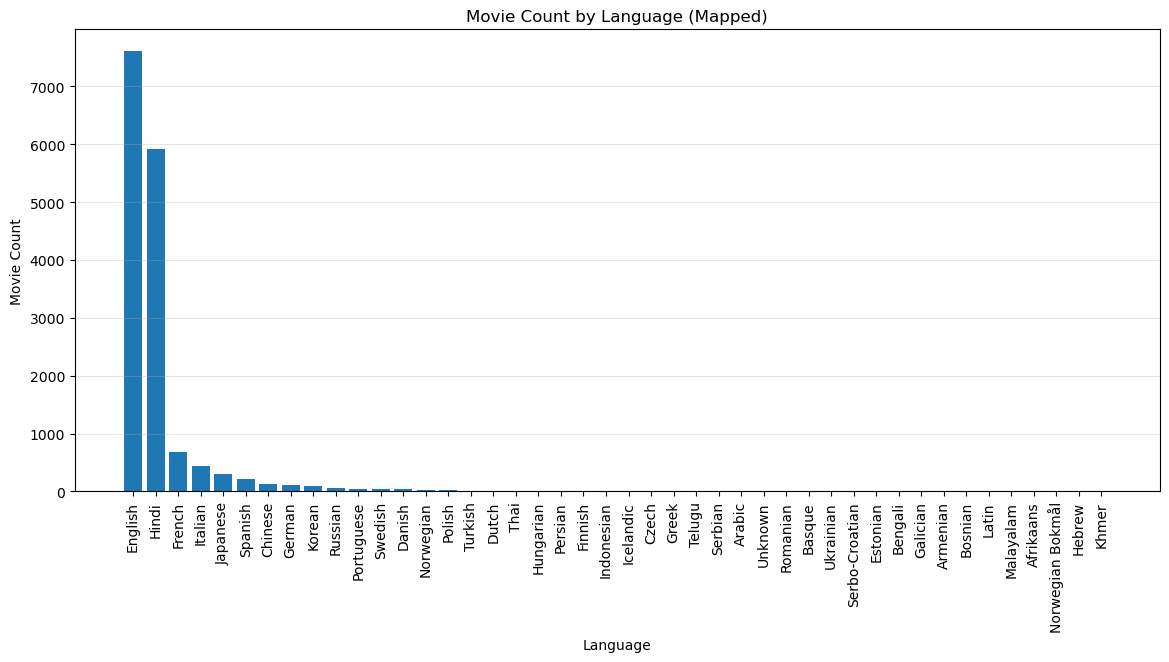

In [65]:
import matplotlib.pyplot as plt

lang_counts = movies['original_language'].value_counts()

plt.figure(figsize=(14,6))
plt.bar(lang_counts.index, lang_counts.values)
plt.xticks(rotation=90)
plt.xlabel("Language")
plt.ylabel("Movie Count")
plt.title("Movie Count by Language (Mapped)")
plt.grid(axis='y', alpha=0.3)
plt.show()

In [66]:
movies['keywords']

0                      [remake, looop lapeta, saade saati]
1           [police, sequel, police officer, cop universe]
2        [spy, fake death, spy thriller, spy universe, ...
3                              [heist, airplane hijacking]
4        [suicide, suicide attempt, college, musical, s...
                               ...                        
15833    [hunter, bosnia and herzegovina, cabin, baptis...
15834    [sheriff, miner, delusion, head injury, remake...
15835    [suicide attempt, gun, texas, mass murder, far...
15836    [based on novel or book, small town, high scho...
15837    [camp, best friend, co-workers relationship, d...
Name: keywords, Length: 15836, dtype: object

In [67]:
movies['overview'][0]

"When her boyfriend loses a mobster's cash, Savi races against the clock to save the day — if only she can break out of a curious cycle of dead ends."

In [68]:
movies.head()

,adult,backdrop_path,movie_id,original_language,original_title,overview,popularity,poster_path,release_date,title,video,vote_average,vote_count,genres,keywords,cast,crew,release_year,score,director
0,False,/kQM7o3NIkruIZLoQ9E2XzZQ8Ujl.jpg,783461,Hindi,लूप लपेटा,"When her boyfriend loses a mobster's cash, Sav...",56.311,/onGdT8sYi89drvSJyEJnft97rOq.jpg,2022-02-04,Looop Lapeta,False,6.2,54.0,"[Action, Comedy, Crime]","[remake, looop lapeta, saade saati]","[Taapsee Pannu, Tahir Raj Bhasin, Shreya Dhanw...","[Tom Tykwer, Mukesh Chhabra, Tanuj Garg]",2022,5.611747,Aakash Bhatia
1,False,/7w06baRS9VPm5RYz8lawTCLiR4j.jpg,592508,Hindi,Sooryavanshi,"A fearless, faithful albeit slightly forgetful...",45.077,/8p3mhjyLjHKtaAv8tFKfvEBtir0.jpg,2021-11-05,Sooryavanshi,False,5.8,133.0,"[Action, Crime, Thriller]","[police, sequel, police officer, cop universe]","[Akshay Kumar, Katrina Kaif, Ajay Devgn, Ranve...","[Akshay Kumar, Karan Johar, Bunty Nagi]",2021,5.609262,Rohit Shetty
2,False,/sP9mRWiCxCuy17tUJfV8TpSZpqc.jpg,864692,Hindi,पठान,A soldier caught by enemies and presumed dead ...,47.611,/m1b9toKYyCujHuLoXB5GSDunO9e.jpg,2023-01-25,Pathaan,False,6.7,70.0,"[Action, Adventure, Thriller]","[spy, fake death, spy thriller, spy universe, ...","[Shah Rukh Khan, Deepika Padukone, John Abraha...","[Aditya Chopra, Siddharth Anand, Siddharth Anand]",2023,5.628545,Siddharth Anand
3,False,/vBmmJYv5asJpdJZsyPPc4MMpfBe.jpg,1018228,Hindi,चोर निकल के भागा,A flight attendant and her boyfriend must stea...,43.789,/1MIDERaEUMw1rYDM99tGZPY80Ap.jpg,2023-03-24,Chor Nikal Ke Bhaga,False,7.2,55.0,"[Crime, Thriller]","[heist, airplane hijacking]","[Yami Gautam, Sunny Kaushal, Sharad Kelkar, In...","[Dinesh Vijan, Raj Kumar Gupta, Ajay Singh]",2023,5.632892,Ajay Singh
4,False,/u7kuUaySqXBVAtqEl9vkTkAzHV9.jpg,20453,Hindi,3 Idiots,Rascal. Joker. Dreamer. Genius... You've never...,37.260,/66A9MqXOyVFCssoloscw79z8Tew.jpg,2009-12-25,3 Idiots,False,8.0,2052.0,"[Drama, Comedy]","[suicide, suicide attempt, college, musical, s...","[Aamir Khan, R. Madhavan, Sharman Joshi, Karee...","[Boman Irani, Kareena Kapoor Khan, Manish Malh...",2009,6.664261,Rajkumar Hirani


In [69]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15836 entries, 0 to 15837
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   adult              15836 non-null  object        
 1   backdrop_path      12986 non-null  object        
 2   movie_id           15836 non-null  object        
 3   original_language  15836 non-null  object        
 4   original_title     15836 non-null  object        
 5   overview           15836 non-null  object        
 6   popularity         15836 non-null  float64       
 7   poster_path        15184 non-null  object        
 8   release_date       15836 non-null  datetime64[ns]
 9   title              15836 non-null  object        
 10  video              15836 non-null  object        
 11  vote_average       15836 non-null  float64       
 12  vote_count         15836 non-null  float64       
 13  genres             15836 non-null  object        
 14  keywords   

In [70]:
movies.isna().sum()

adult                   0
backdrop_path        2850
movie_id                0
original_language       0
original_title          0
overview                0
popularity              0
poster_path           652
release_date            0
title                   0
video                   0
vote_average            0
vote_count              0
genres                  0
keywords                0
cast                    0
crew                    0
release_year            0
score                   0
director                0
dtype: int64

In [71]:
import os

# Path relative to project root
save_path = os.path.join(r"..\data", "movies_clean.csv")

movies.to_csv(save_path, index=False)

print(f"File saved at: {save_path}")


File saved at: ..\data\movies_clean.csv
